<a href="https://colab.research.google.com/github/winter-pro/Statistical-Learning-e23091/blob/main/Assignment_8_MaxEnt_Inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Max Entropy Inference Assignment

This notebook solves the maximum entropy inference problem using Python.

The main idea is to find a probability distribution that has the maximum entropy while satisfying the given constraints.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

## Entropy Function

For a discrete probability distribution \(p(x)\), entropy is defined as:

\[
H(p) = -\sum_i p_i \log(p_i)
\]

In maximum entropy inference, we maximize this entropy subject to constraints such as:

\[
\sum_i p_i = 1
\]

and sometimes:

\[
\sum_i x_i p_i = \mu
\]

In [2]:
def entropy(p):
    """
    Calculate entropy H(p) = -sum p log(p)
    """
    p = np.array(p)
    p = p[p > 0]   # avoid log(0)
    return -np.sum(p * np.log(p))


def negative_entropy(p):
    """
    We minimize negative entropy because scipy minimize is used.
    """
    return -entropy(p)

## Example Problem

Assume the random variable \(X\) can take values from 0 to 10.

We want to find the probability distribution with maximum entropy, subject to:

1. Total probability must be 1  
2. Expected value of \(X\) must be equal to a given mean

In [3]:
# Possible values of X
x = np.arange(0, 11)

# Given expected value
given_mean = 5

# Number of probabilities
n = len(x)

# Initial guess: uniform distribution
p0 = np.ones(n) / n

# Constraints
constraints = [
    {
        'type': 'eq',
        'fun': lambda p: np.sum(p) - 1
    },
    {
        'type': 'eq',
        'fun': lambda p: np.sum(x * p) - given_mean
    }
]

# Probability bounds: each probability must be between 0 and 1
bounds = [(0, 1) for _ in range(n)]

# Optimization
result = minimize(
    negative_entropy,
    p0,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

p_maxent = result.x

print("Optimization successful:", result.success)
print("Maximum entropy distribution:")
print(p_maxent)
print("Entropy =", entropy(p_maxent))
print("Mean =", np.sum(x * p_maxent))
print("Sum of probabilities =", np.sum(p_maxent))

Optimization successful: True
Maximum entropy distribution:
[0.09090909 0.09090909 0.09090909 0.09090909 0.09090909 0.09090909
 0.09090909 0.09090909 0.09090909 0.09090909 0.09090909]
Entropy = 2.3978952727983707
Mean = 5.0
Sum of probabilities = 1.0


## Plot of Maximum Entropy Distribution

The following graph shows the probability distribution obtained by the maximum entropy method.

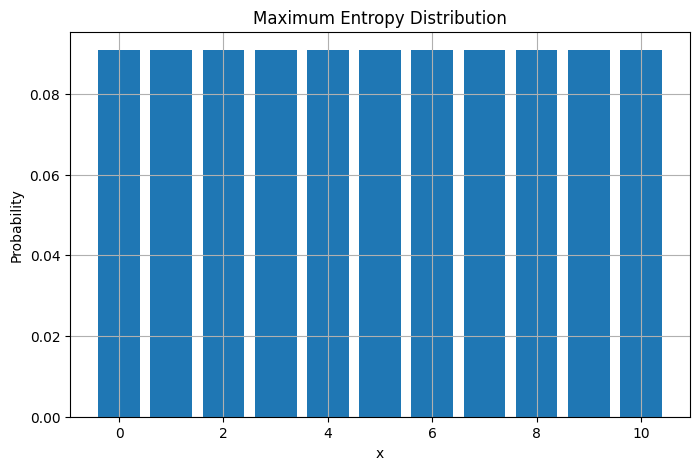

In [4]:
plt.figure(figsize=(8, 5))
plt.bar(x, p_maxent)
plt.xlabel("x")
plt.ylabel("Probability")
plt.title("Maximum Entropy Distribution")
plt.grid(True)
plt.show()

## Explanation

The maximum entropy distribution is the least biased distribution that satisfies the given information.

Here, the constraints are:

\[
\sum_i p_i = 1
\]

and

\[
\sum_i x_i p_i = \mu
\]

The optimization finds the probability values that maximize entropy while satisfying these constraints.

In [5]:
# Display results in table form

import pandas as pd

df = pd.DataFrame({
    "x": x,
    "Probability": p_maxent
})

df

,x,Probability
0,0,0.090909
1,1,0.090909
2,2,0.090909
3,3,0.090909
4,4,0.090909
5,5,0.090909
6,6,0.090909
7,7,0.090909
8,8,0.090909
9,9,0.090909
